# Fuzzy Mamdani – Penilaian Performa Karyawan
## Perbandingan Fuzzy Mamdani dan Fuzzy Sugeno dalam HR Analytics

Notebook ini mengimplementasikan sistem **Fuzzy Mamdani** secara *from scratch* untuk memprediksi `Performance Score` karyawan berdasarkan 6 variabel input.

### Alur Sistem Fuzzy Mamdani
```
Input Crisp → Fuzzifikasi → Evaluasi Rule (Inferensi) → Agregasi → Defuzzifikasi Centroid → Output Crisp
```

### Perbedaan Mamdani vs Sugeno
| Aspek | Mamdani | Sugeno |
|---|---|---|
| Output tiap rule | Himpunan fuzzy | Konstanta / fungsi linear |
| Defuzzifikasi | Centroid / MOM | Weighted Average |
| Komputasi | Lebih berat | Lebih efisien |
| Interpretasi | Lebih intuitif | Lebih matematis |

---

---
## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

INPUT_COLS = ['KPI Score', 'Attendance (%)', 'Peer Rating',
              'Task Completion (%)', 'Manager Feedback', 'Training Hours']
OUTPUT_COL = 'Performance Score'

raw = pd.read_csv('Employee_Performance_Dataset.csv')
df  = raw[INPUT_COLS + [OUTPUT_COL]].dropna().reset_index(drop=True)

print(f'Shape dataset : {df.shape}')
display(df.head())

# ── Kompatibilitas NumPy ───────────────────────────────────────────
if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

Shape dataset : (5000, 7)


,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Manager Feedback,Training Hours,Performance Score
0,91.03,94.40,4.5,78.19,3.7,18,61
1,83.36,78.45,4.7,71.39,4.5,15,91
2,65.39,99.50,4.4,80.20,3.5,7,100
3,82.90,79.83,4.3,71.51,5.0,9,100
4,90.90,89.92,3.7,78.03,3.1,29,80


---
## 2. Membership Functions (Fungsi Keanggotaan)

Dua bentuk fungsi keanggotaan digunakan:
- **Trapezoidal (`trapmf`)** — untuk himpunan ujung kiri (bahu kiri) dan ujung kanan (bahu kanan), agar nilai ekstrem domain tetap memiliki derajat keanggotaan = 1.
- **Triangular (`trimf`)** — untuk himpunan tengah (*Sedang / Cukup*).

Batas-batas ditentukan berdasarkan **Q1, Median, Q3** dari statistik deskriptif data aktual (pendekatan *percentile-based*).

In [2]:
def trimf(x: float, a: float, b: float, c: float) -> float:
    """
    Triangular Membership Function.
    Naik linear dari a ke b (puncak = 1), turun linear dari b ke c.
    """
    left  = (x - a) / (b - a) if b != a else 1.0
    right = (c - x) / (c - b) if c != b else 1.0
    return float(max(0.0, min(left, right)))


def trapmf(x: float, a: float, b: float, c: float, d: float) -> float:
    """
    Trapezoidal Membership Function.
    - Bahu kiri  (a == b): plateau dimulai dari awal domain.
    - Bahu kanan (c == d): plateau hingga akhir domain.
    - Normal     (a < b, c < d): naik a→b, plateau b–c, turun c→d.
    """
    # Bahu kiri
    if a == b:
        if x <= c:       return 1.0
        elif c < x < d:  return (d - x) / (d - c)
        return 0.0
    # Bahu kanan
    if c == d:
        if x >= b:       return 1.0
        elif a < x < b:  return (x - a) / (b - a)
        return 0.0
    # Trapezoid normal
    if   x <= a or x >= d: return 0.0
    elif a < x <= b:       return (x - a) / (b - a)
    elif b < x <= c:       return 1.0
    elif c < x <  d:       return (d - x) / (d - c)
    return 0.0

### 2.1 Parameter Membership Function

Parameter batas setiap himpunan disimpan dalam dictionary `MEMBERSHIP` yang bersumber dari notebook Preprocessing.
Parameter **output** Mamdani juga berupa himpunan fuzzy (bukan konstanta), sehingga turut didefinisikan di sini.

In [3]:
MEMBERSHIP = {
    'KPI Score': {
        # Range: [60.01, 94.99]  Q1=68.33  Median=77.34  Q3=86.05
        'Sangat_Rendah' : [60, 60, 66.80, 68.33], #trapezoidal – bahu kiri
        'Rendah' : [66.80, 68.33, 77.34],   # triangular
        'Sedang' : [68.33, 77.34, 86.05],   # triangular
        'Tinggi' : [77.34, 86.05, 87.81],   # triangular
        'Sangat_Tinggi' : [86.05, 87.81, 95.00, 95.00],   # trapezoidal – bahu kanan
    },
    'Attendance (%)': {
        # Range: [75.01, 100.00]  Q1=81.13  Median=87.41  Q3=93.75
        'Sangat_Rendah' : [75, 75, 79.95, 81.13],
        'Rendah' : [79.95, 81.13, 87.41],
        'Sedang' : [81.13, 87.41, 93.75],
        'Tinggi' : [87.41, 93.75, 95.04],
        'Sangat_Tinggi' : [93.75, 95.04, 100, 100],
    },
    'Peer Rating': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Task Completion (%)': {
        # Range: [70.01, 100.00]  Q1=77.32  Median=85.12  Q3=92.47
        'Sangat_Rendah' : [70, 70, 75.99, 77.32],
        'Rendah' : [75.99, 77.32, 85.12],
        'Sedang' : [77.32, 85.12, 92.47],
        'Tinggi' : [85.12, 92.47, 94.05],
        'Sangat_Tinggi' : [92.47, 94.05, 100, 100],
    },
    'Manager Feedback': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Training Hours': {
        # Range: [0, 30]  Q1=7.00  Median=15.00  Q3=23.00
        'Sangat_Sedikit' : [0, 0, 5, 7],
        'Sedikit' : [5, 7, 15],
        'Cukup' : [7, 15, 23],
        'Banyak' : [15, 23, 24],
        'Sangat_Banyak' : [23, 24, 30, 30],
    },
}

# Output Mamdani – himpunan fuzzy pada domain [50, 100]
# Ditentukan dari statistik Performance Score: min=50, Q1=62, Med=75, Q3=87, max=100
OUTPUT_DOMAIN = np.linspace(50, 100, 500)   # universe of discourse output

OUTPUT_MF = {
    'Sangat_Rendah': [50, 50, 56, 62],      # trapmf – bahu kiri
    'Rendah'       : [56, 62, 68.5, 75],    # trapmf
    'Sedang'       : [62, 75, 87],           # trimf  – puncak di median
    'Tinggi'       : [75, 83, 87, 93.5],    # trapmf
    'Sangat_Tinggi': [87, 93.5, 100, 100],  # trapmf – bahu kanan
}

print('Parameter membership function dimuat.')
print('Output himpunan Mamdani:', list(OUTPUT_MF.keys()))

Parameter membership function dimuat.
Output himpunan Mamdani: ['Sangat_Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat_Tinggi']


### 2.2 Visualisasi Membership Function

Kurva membership function divisualisasikan untuk semua 6 variabel input dan variabel output agar dapat divalidasi secara visual.

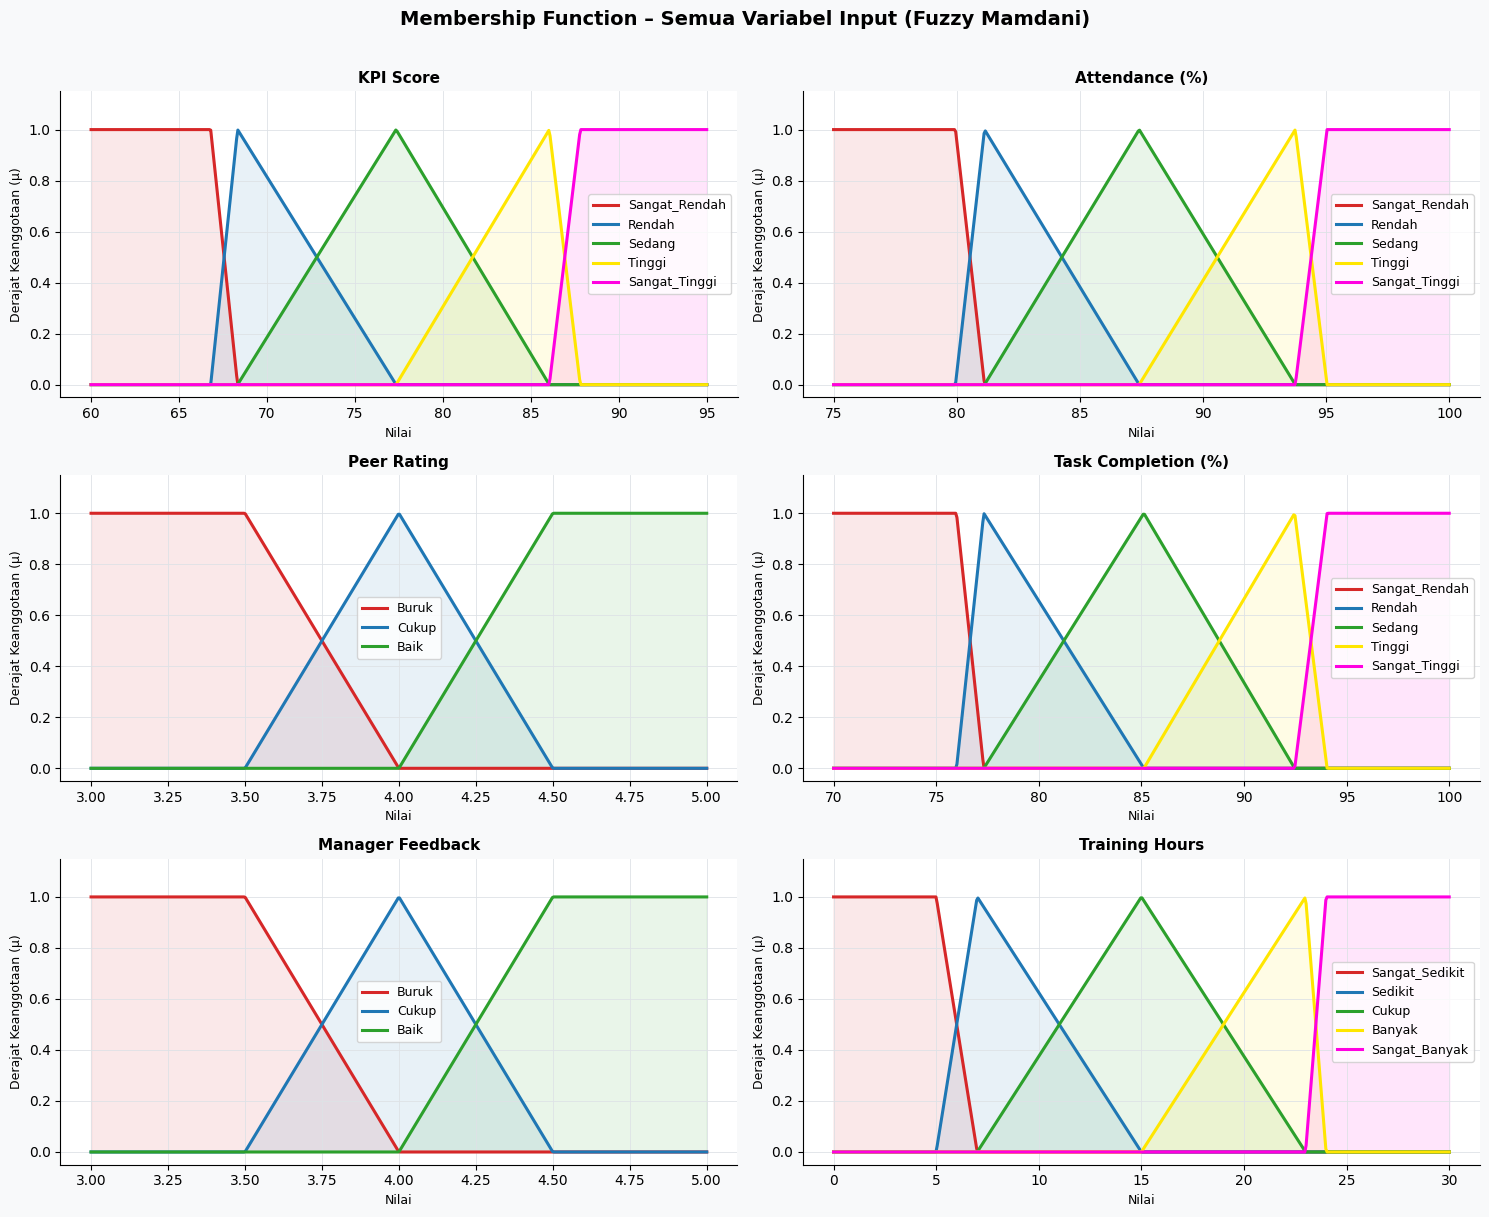

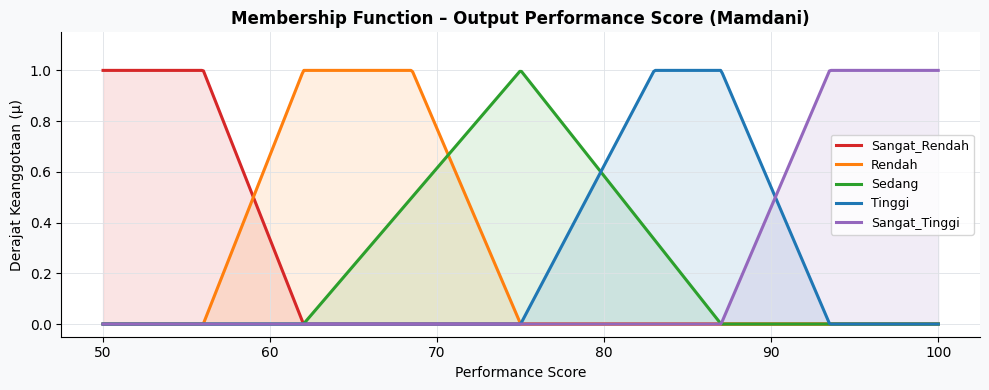

In [4]:
def mf_values(x_arr, params):
    """Hitung derajat keanggotaan untuk array x sesuai panjang params."""
    fn = trapmf if len(params) == 4 else trimf
    return [fn(x, *params) for x in x_arr]

RANGES = {
    'KPI Score': (60, 95), 'Attendance (%)': (75, 100),
    'Peer Rating': (3, 5), 'Task Completion (%)': (70, 100),
    'Manager Feedback': (3, 5), 'Training Hours': (0, 30),
}
LABEL_COLORS = ['#D62728', '#1F77B4', '#2CA02C', "#FFE600", "#FF00E1"]   # merah, biru, hijau

fig, axes = plt.subplots(3, 2, figsize=(15, 12), facecolor='#F8F9FA')
axes = axes.flatten()

for idx, (var, himpunan) in enumerate(MEMBERSHIP.items()):
    ax  = axes[idx]
    ax.set_facecolor('white')
    lo, hi = RANGES[var]
    x  = np.linspace(lo, hi, 500)

    for (nama, params), clr in zip(himpunan.items(), LABEL_COLORS):
        y = mf_values(x, params)
        ax.plot(x, y, color=clr, lw=2.2, label=nama)
        ax.fill_between(x, y, alpha=0.10, color=clr)

    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=9)
    ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, color='#DEE2E6', lw=0.6)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Membership Function – Semua Variabel Input (Fuzzy Mamdani)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Visualisasi MF Output Mamdani ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4), facecolor='#F8F9FA')
ax2.set_facecolor('white')
out_colors = ['#D62728', '#FF7F0E', '#2CA02C', '#1F77B4', '#9467BD']
for (nama, params), clr in zip(OUTPUT_MF.items(), out_colors):
    y = mf_values(OUTPUT_DOMAIN, params)
    ax2.plot(OUTPUT_DOMAIN, y, color=clr, lw=2.2, label=nama)
    ax2.fill_between(OUTPUT_DOMAIN, y, alpha=0.12, color=clr)
ax2.set_title('Membership Function – Output Performance Score (Mamdani)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Performance Score', fontsize=10)
ax2.set_ylabel('Derajat Keanggotaan (μ)', fontsize=10)
ax2.set_ylim(-0.05, 1.15)
ax2.legend(fontsize=9)
ax2.grid(True, color='#DEE2E6', lw=0.6)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 3. Fuzzifikasi

Fuzzifikasi adalah proses mengubah nilai input *crisp* menjadi **derajat keanggotaan** di setiap himpunan fuzzy yang telah didefinisikan. Hasilnya adalah dictionary berisi nilai μ (mu) untuk setiap himpunan per variabel.

In [5]:
def fuzzify(row: pd.Series) -> dict:
    """
    Fuzzifikasi satu baris data.
    Mengembalikan dict berisi derajat keanggotaan tiap himpunan
    untuk setiap variabel input.
    """
    kpi  = row['KPI Score']
    att  = row['Attendance (%)']
    peer = row['Peer Rating']
    task = row['Task Completion (%)']
    mgr  = row['Manager Feedback']
    trn  = row['Training Hours']

    mf = MEMBERSHIP   # alias pendek

    return {
        'kpi' : {
            'SR': trapmf(kpi,  *mf['KPI Score']['Sangat_Rendah']),
            'R': trimf(kpi,  *mf['KPI Score']['Rendah']),
            'S': trimf (kpi,  *mf['KPI Score']['Sedang']),
            'T': trimf(kpi,  *mf['KPI Score']['Tinggi']),
            'ST': trapmf(kpi,  *mf['KPI Score']['Sangat_Tinggi']),
        },
        'att' : {
            'SR': trapmf(att,  *mf['Attendance (%)']['Sangat_Rendah']),
            'R': trimf(att,  *mf['Attendance (%)']['Rendah']),
            'S': trimf (att,  *mf['Attendance (%)']['Sedang']),
            'T': trimf(att,  *mf['Attendance (%)']['Tinggi']),
            'ST': trapmf(att,  *mf['Attendance (%)']['Sangat_Tinggi']),
        },
        'peer': {
            'R': trapmf(peer, *mf['Peer Rating']['Buruk']),
            'S': trimf (peer, *mf['Peer Rating']['Cukup']),
            'T': trapmf(peer, *mf['Peer Rating']['Baik']),
        },
        'task': {
            'SR': trapmf(task, *mf['Task Completion (%)']['Sangat_Rendah']),
            'R': trimf(task, *mf['Task Completion (%)']['Rendah']),
            'S': trimf (task, *mf['Task Completion (%)']['Sedang']),
            'T': trimf(task, *mf['Task Completion (%)']['Tinggi']),
            'ST': trapmf(task, *mf['Task Completion (%)']['Sangat_Tinggi']),
        },
        'mgr' : {
            'R': trapmf(mgr,  *mf['Manager Feedback']['Buruk']),
            'S': trimf (mgr,  *mf['Manager Feedback']['Cukup']),
            'T': trapmf(mgr,  *mf['Manager Feedback']['Baik']),
        },
        'trn' : {
            'SR': trapmf(trn,  *mf['Training Hours']['Sangat_Sedikit']),
            'R': trimf(trn,  *mf['Training Hours']['Sedikit']),
            'S': trimf (trn,  *mf['Training Hours']['Cukup']),
            'T': trimf(trn,  *mf['Training Hours']['Banyak']),
            'ST': trapmf(trn,  *mf['Training Hours']['Sangat_Banyak']),
        },
    }

In [6]:
# ── Contoh fuzzifikasi pada 1 baris data ──────────────────────────
sample_row = pd.Series({
    'KPI Score': 85, 'Attendance (%)': 90, 'Peer Rating': 4.5,
    'Task Completion (%)': 92, 'Manager Feedback': 4.6, 'Training Hours': 18
})

f_sample = fuzzify(sample_row)

label_map = {
    'kpi':'KPI Score', 'att':'Attendance (%)', 'peer':'Peer Rating',
    'task':'Task Completion (%)', 'mgr':'Manager Feedback', 'trn':'Training Hours'
}
himpunan_map = {
    'kpi' :['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'att' :['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'peer':['Buruk','Cukup','Baik'],
    'task':['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'mgr' :['Buruk','Cukup','Baik'],
    'trn' :['Sangat Sedikit','Sedikit','Cukup','Banyak','Sangat Banyak'],
}

print('=== Hasil Fuzzifikasi Contoh Data ===')
for key, vals in f_sample.items():
    labels = himpunan_map[key]
    print(f'  {label_map[key]:<22} → ', end='')
    for lbl, (k, v) in zip(labels, vals.items()):
        print(f'{lbl}={v:.4f}  ', end='')
    print()

=== Hasil Fuzzifikasi Contoh Data ===
  KPI Score              → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.1206  Tinggi=0.8794  Sangat Tinggi=0.0000  
  Attendance (%)         → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.5915  Tinggi=0.4085  Sangat Tinggi=0.0000  
  Peer Rating            → Buruk=0.0000  Cukup=0.0000  Baik=1.0000  
  Task Completion (%)    → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.0639  Tinggi=0.9361  Sangat Tinggi=0.0000  
  Manager Feedback       → Buruk=0.0000  Cukup=0.0000  Baik=1.0000  
  Training Hours         → Sangat Sedikit=0.0000  Sedikit=0.0000  Cukup=0.6250  Banyak=0.3750  Sangat Banyak=0.0000  


---
## 4. Rule Base (Basis Aturan)

Sistem Fuzzy Mamdani menggunakan **48 rule** dengan format:

> **IF** *antecedent_1* **AND** *antecedent_2* **[AND ...]** **THEN** *output = himpunan fuzzy*

Dalam Mamdani, **output setiap rule adalah himpunan fuzzy** (bukan konstanta seperti Sugeno). Firing strength rule memotong (clip) himpunan output pada nilai tersebut.

**Operator AND** menggunakan fungsi **minimum** (t-norm standar Mamdani):
$$\mu_{rule} = \min(\mu_{A_1}, \mu_{A_2}, \ldots)$$

In [7]:
# Tampilkan daftar rule dalam format teks
RULE_DESCRIPTIONS = [
    # ── SANGAT TINGGI ──────────────────────────────────────────────
    'R01: IF KPI ST      AND Attendance ST  AND Task ST    THEN Sangat_Tinggi',
    'R02: IF KPI ST      AND Manager Baik   AND Peer Baik  THEN Sangat_Tinggi',
    'R03: IF KPI ST      AND Task ST        AND Manager T  THEN Sangat_Tinggi',
    'R04: IF KPI ST      AND Attendance ST  AND Manager T  THEN Sangat_Tinggi',
    'R05: IF Task ST     AND Manager T      AND Peer Baik  THEN Sangat_Tinggi',
    'R06: IF KPI ST      AND Attendance T   AND Task ST    THEN Sangat_Tinggi',
    'R07: IF KPI T       AND Attendance ST  AND Task ST    THEN Sangat_Tinggi',
    'R08: IF KPI ST      AND Task ST        AND Training T THEN Sangat_Tinggi',
    'R09: IF KPI ST      AND Attendance ST  AND Peer Baik  THEN Sangat_Tinggi',
    'R10: IF Task ST     AND Attendance ST  AND Manager T  THEN Sangat_Tinggi',
    # ── TINGGI ─────────────────────────────────────────────────────
    'R11: IF KPI T       AND Attendance T   AND Task T     THEN Tinggi',
    'R12: IF KPI T       AND Manager T      AND Task T     THEN Tinggi',
    'R13: IF KPI ST      AND Attendance S   AND Task T     THEN Tinggi',
    'R14: IF KPI T       AND Attendance ST  AND Task S     THEN Tinggi',
    'R15: IF Task T      AND Manager T      AND Attendance S THEN Tinggi',
    'R16: IF KPI T       AND Peer Baik      AND Attendance T THEN Tinggi',
    'R17: IF KPI T       AND Task T         AND Training T THEN Tinggi',
    'R18: IF KPI ST      AND Manager Cukup  AND Task T     THEN Tinggi',
    'R19: IF Attendance T AND Task ST       AND Manager S  THEN Tinggi',
    'R20: IF KPI T       AND Attendance T   AND Training ST THEN Tinggi',
    # ── SEDANG ─────────────────────────────────────────────────────
    'R21: IF KPI S       AND Attendance S   AND Task S     THEN Sedang',
    'R22: IF KPI T       AND Attendance R   AND Task S     THEN Sedang',
    'R23: IF KPI S       AND Attendance T   AND Task R     THEN Sedang',
    'R24: IF KPI R       AND Attendance ST  AND Task T     THEN Sedang',
    'R25: IF KPI S       AND Manager S      AND Task T     THEN Sedang',
    'R26: IF KPI S       AND Attendance S   AND Manager T  THEN Sedang',
    'R27: IF KPI T       AND Attendance S   AND Task R     THEN Sedang',
    'R28: IF Task S      AND Attendance S   AND Peer Cukup THEN Sedang',
    'R29: IF KPI S       AND Task S         AND Training S THEN Sedang',
    'R30: IF KPI R       AND Manager Baik   AND Task ST    THEN Sedang',
    # ── RENDAH ─────────────────────────────────────────────────────
    'R31: IF KPI R       AND Attendance R   AND Task R     THEN Rendah',
    'R32: IF KPI SR      AND Attendance S   AND Task S     THEN Rendah',
    'R33: IF KPI R       AND Manager S      AND Task R     THEN Rendah',
    'R34: IF KPI S       AND Attendance SR  AND Task R     THEN Rendah',
    'R35: IF KPI R       AND Task R         AND Training R THEN Rendah',
    'R36: IF KPI R       AND Attendance R   AND Peer Cukup THEN Rendah',
    'R37: IF Task R      AND Manager S      AND Attendance R THEN Rendah',
    'R38: IF KPI S       AND Attendance R   AND Task SR    THEN Rendah',
    'R39: IF KPI R       AND Manager Buruk  AND Attendance S THEN Rendah',
    'R40: IF Task SR     AND Attendance R   AND Training S THEN Rendah',
    # ── SANGAT RENDAH ──────────────────────────────────────────────
    'R41: IF KPI SR      AND Attendance SR  AND Task SR    THEN Sangat_Rendah',
    'R42: IF KPI SR      AND Manager Buruk  AND Task R     THEN Sangat_Rendah',
    'R43: IF KPI SR      AND Attendance R   AND Task SR    THEN Sangat_Rendah',
    'R44: IF KPI R       AND Attendance SR  AND Task SR    THEN Sangat_Rendah',
    'R45: IF KPI SR      AND Task SR        AND Training SR THEN Sangat_Rendah',
    'R46: IF KPI SR      AND Attendance SR  AND Manager Buruk THEN Sangat_Rendah',
    'R47: IF Task SR     AND Manager Buruk  AND Peer Buruk THEN Sangat_Rendah',
    'R48: IF KPI SR      AND Attendance SR  AND Peer Buruk THEN Sangat_Rendah',
]

print(f'Total rules : {len(RULE_DESCRIPTIONS)}\n')
for r in RULE_DESCRIPTIONS:
    print(' ', r)

Total rules : 48

  R01: IF KPI ST      AND Attendance ST  AND Task ST    THEN Sangat_Tinggi
  R02: IF KPI ST      AND Manager Baik   AND Peer Baik  THEN Sangat_Tinggi
  R03: IF KPI ST      AND Task ST        AND Manager T  THEN Sangat_Tinggi
  R04: IF KPI ST      AND Attendance ST  AND Manager T  THEN Sangat_Tinggi
  R05: IF Task ST     AND Manager T      AND Peer Baik  THEN Sangat_Tinggi
  R06: IF KPI ST      AND Attendance T   AND Task ST    THEN Sangat_Tinggi
  R07: IF KPI T       AND Attendance ST  AND Task ST    THEN Sangat_Tinggi
  R08: IF KPI ST      AND Task ST        AND Training T THEN Sangat_Tinggi
  R09: IF KPI ST      AND Attendance ST  AND Peer Baik  THEN Sangat_Tinggi
  R10: IF Task ST     AND Attendance ST  AND Manager T  THEN Sangat_Tinggi
  R11: IF KPI T       AND Attendance T   AND Task T     THEN Tinggi
  R12: IF KPI T       AND Manager T      AND Task T     THEN Tinggi
  R13: IF KPI ST      AND Attendance S   AND Task T     THEN Tinggi
  R14: IF KPI T       AND At

---
## 5. Inferensi Mamdani

Setiap rule dievaluasi menggunakan operator **minimum** pada antecedent-nya. Hasil evaluasi adalah **firing strength (α)** — seberapa kuat rule tersebut berlaku untuk input yang diberikan.

Pada Mamdani, firing strength digunakan untuk **memotong (clip)** himpunan fuzzy output menggunakan operasi minimum:
$$\mu_{\text{output clipped}}(z) = \min(\alpha_{rule}, \mu_{\text{output}}(z))$$

Hasil potongan semua rule kemudian **diagregasi** (digabungkan) menggunakan operasi **maximum**:
$$\mu_{\text{agregat}}(z) = \max_i \left[ \mu_{\text{rule}_i \text{ clipped}}(z) \right]$$

In [8]:
def evaluate_rules(f: dict) -> list:
    """
    Evaluasi 48 rule fuzzy Mamdani.
    Key himpunan:
      SR = Sangat Rendah   R = Rendah   S = Sedang   T = Tinggi   ST = Sangat Tinggi
      (Peer Rating & Manager Feedback tetap 3 level: R=Buruk, S=Cukup, T=Baik)
    Input  : f = hasil fuzzify()
    Output : list of (firing_strength, nama_output_himpunan)
             — berbeda dari Sugeno yang mengembalikan (strength, konstanta)
    """
    rules = [
        # ── SANGAT TINGGI ──────────────────────────────────────────
        (min(f['kpi']['ST'], f['att']['ST'], f['task']['ST']),          'Sangat_Tinggi'),  # R01
        (min(f['kpi']['ST'], f['mgr']['T'],  f['peer']['T']),           'Sangat_Tinggi'),  # R02
        (min(f['kpi']['ST'], f['task']['ST'], f['mgr']['T']),           'Sangat_Tinggi'),  # R03
        (min(f['kpi']['ST'], f['att']['ST'], f['mgr']['T']),            'Sangat_Tinggi'),  # R04
        (min(f['task']['ST'],f['mgr']['T'],  f['peer']['T']),           'Sangat_Tinggi'),  # R05
        (min(f['kpi']['ST'], f['att']['T'],  f['task']['ST']),          'Sangat_Tinggi'),  # R06
        (min(f['kpi']['T'],  f['att']['ST'], f['task']['ST']),          'Sangat_Tinggi'),  # R07
        (min(f['kpi']['ST'], f['task']['ST'], f['trn']['T']),           'Sangat_Tinggi'),  # R08
        (min(f['kpi']['ST'], f['att']['ST'], f['peer']['T']),           'Sangat_Tinggi'),  # R09
        (min(f['task']['ST'],f['att']['ST'], f['mgr']['T']),            'Sangat_Tinggi'),  # R10

        # ── TINGGI ─────────────────────────────────────────────────
        (min(f['kpi']['T'],  f['att']['T'],  f['task']['T']),           'Tinggi'),         # R11
        (min(f['kpi']['T'],  f['mgr']['T'],  f['task']['T']),           'Tinggi'),         # R12
        (min(f['kpi']['ST'], f['att']['S'],  f['task']['T']),           'Tinggi'),         # R13
        (min(f['kpi']['T'],  f['att']['ST'], f['task']['S']),           'Tinggi'),         # R14
        (min(f['task']['T'], f['mgr']['T'],  f['att']['S']),            'Tinggi'),         # R15
        (min(f['kpi']['T'],  f['peer']['T'], f['att']['T']),            'Tinggi'),         # R16
        (min(f['kpi']['T'],  f['task']['T'], f['trn']['T']),            'Tinggi'),         # R17
        (min(f['kpi']['ST'], f['mgr']['S'],  f['task']['T']),           'Tinggi'),         # R18
        (min(f['att']['T'],  f['task']['ST'], f['mgr']['S']),           'Tinggi'),         # R19
        (min(f['kpi']['T'],  f['att']['T'],  f['trn']['ST']),           'Tinggi'),         # R20

        # ── SEDANG ─────────────────────────────────────────────────
        (min(f['kpi']['S'],  f['att']['S'],  f['task']['S']),           'Sedang'),         # R21
        (min(f['kpi']['T'],  f['att']['R'],  f['task']['S']),           'Sedang'),         # R22
        (min(f['kpi']['S'],  f['att']['T'],  f['task']['R']),           'Sedang'),         # R23
        (min(f['kpi']['R'],  f['att']['ST'], f['task']['T']),           'Sedang'),         # R24
        (min(f['kpi']['S'],  f['mgr']['S'],  f['task']['T']),           'Sedang'),         # R25
        (min(f['kpi']['S'],  f['att']['S'],  f['mgr']['T']),            'Sedang'),         # R26
        (min(f['kpi']['T'],  f['att']['S'],  f['task']['R']),           'Sedang'),         # R27
        (min(f['task']['S'], f['att']['S'],  f['peer']['S']),           'Sedang'),         # R28
        (min(f['kpi']['S'],  f['task']['S'], f['trn']['S']),            'Sedang'),         # R29
        (min(f['kpi']['R'],  f['mgr']['T'],  f['task']['ST']),          'Sedang'),         # R30

        # ── RENDAH ─────────────────────────────────────────────────
        (min(f['kpi']['R'],  f['att']['R'],  f['task']['R']),           'Rendah'),         # R31
        (min(f['kpi']['SR'], f['att']['S'],  f['task']['S']),           'Rendah'),         # R32
        (min(f['kpi']['R'],  f['mgr']['S'],  f['task']['R']),           'Rendah'),         # R33
        (min(f['kpi']['S'],  f['att']['SR'], f['task']['R']),           'Rendah'),         # R34
        (min(f['kpi']['R'],  f['task']['R'], f['trn']['R']),            'Rendah'),         # R35
        (min(f['kpi']['R'],  f['att']['R'],  f['peer']['S']),           'Rendah'),         # R36
        (min(f['task']['R'], f['mgr']['S'],  f['att']['R']),            'Rendah'),         # R37
        (min(f['kpi']['S'],  f['att']['R'],  f['task']['SR']),          'Rendah'),         # R38
        (min(f['kpi']['R'],  f['mgr']['R'],  f['att']['S']),            'Rendah'),         # R39
        (min(f['task']['SR'],f['att']['R'],  f['trn']['S']),            'Rendah'),         # R40

        # ── SANGAT RENDAH ──────────────────────────────────────────
        (min(f['kpi']['SR'], f['att']['SR'], f['task']['SR']),          'Sangat_Rendah'),  # R41
        (min(f['kpi']['SR'], f['mgr']['R'],  f['task']['R']),           'Sangat_Rendah'),  # R42
        (min(f['kpi']['SR'], f['att']['R'],  f['task']['SR']),          'Sangat_Rendah'),  # R43
        (min(f['kpi']['R'],  f['att']['SR'], f['task']['SR']),          'Sangat_Rendah'),  # R44
        (min(f['kpi']['SR'], f['task']['SR'], f['trn']['SR']),          'Sangat_Rendah'),  # R45
        (min(f['kpi']['SR'], f['att']['SR'], f['mgr']['R']),            'Sangat_Rendah'),  # R46
        (min(f['task']['SR'],f['mgr']['R'],  f['peer']['R']),           'Sangat_Rendah'),  # R47
        (min(f['kpi']['SR'], f['att']['SR'], f['peer']['R']),           'Sangat_Rendah'),  # R48
    ]
    return rules

In [9]:
# Contoh inferensi pada data sampel
rules_sample = evaluate_rules(f_sample)

print('=== Firing Strength Tiap Rule (Contoh Data) ===')
print(f"{'Rule':<6} {'Firing Strength':>16} {'Output Himpunan':>18}")
print('-' * 44)
for i, (w, label) in enumerate(rules_sample, 1):
    active = ' ← aktif' if w > 0 else ''
    print(f"R{i:02d}    {w:>16.4f} {label:>18}{active}")

=== Firing Strength Tiap Rule (Contoh Data) ===
Rule    Firing Strength    Output Himpunan
--------------------------------------------
R01              0.0000      Sangat_Tinggi
R02              0.0000      Sangat_Tinggi
R03              0.0000      Sangat_Tinggi
R04              0.0000      Sangat_Tinggi
R05              0.0000      Sangat_Tinggi
R06              0.0000      Sangat_Tinggi
R07              0.0000      Sangat_Tinggi
R08              0.0000      Sangat_Tinggi
R09              0.0000      Sangat_Tinggi
R10              0.0000      Sangat_Tinggi
R11              0.4085             Tinggi ← aktif
R12              0.8794             Tinggi ← aktif
R13              0.0000             Tinggi
R14              0.0000             Tinggi
R15              0.5915             Tinggi ← aktif
R16              0.4085             Tinggi ← aktif
R17              0.3750             Tinggi ← aktif
R18              0.0000             Tinggi
R19              0.0000             Tinggi
R20    

---
## 6. Defuzzifikasi – Centroid (Center of Gravity)

Pada Mamdani, defuzzifikasi menggunakan metode **Centroid** (Center of Area / COA):

$$\text{Output} = \frac{\int z \cdot \mu_{\text{agregat}}(z)\, dz}{\int \mu_{\text{agregat}}(z)\, dz}$$

Prosesnya:
1. **Agregasi**: untuk setiap titik pada domain output, ambil nilai maksimum dari semua potongan rule yang aktif.
2. **Centroid**: hitung titik berat dari kurva hasil agregasi.

Ini berbeda dari Sugeno yang hanya menghitung Weighted Average dari konstanta crisp.

In [10]:
def aggregate(rules: list, domain: np.ndarray) -> np.ndarray:
    """
    Agregasi Mamdani: clip tiap output himpunan pada firing strength,
    lalu ambil maksimum di seluruh rule (union).
    """
    aggregated = np.zeros(len(domain))
    for alpha, label in rules:
        if alpha <= 0:
            continue
        params = OUTPUT_MF[label]
        fn = trapmf if len(params) == 4 else trimf
        clipped = np.array([min(alpha, fn(z, *params)) for z in domain])
        aggregated = np.maximum(aggregated, clipped)
    return aggregated


def defuzzify_centroid(aggregated: np.ndarray, domain: np.ndarray) -> float:
    """
    Defuzzifikasi Centroid (Center of Gravity).
    Jika seluruh area = 0, kembalikan nilai tengah domain (fallback).
    """
    total_area = np.trapezoid(aggregated, domain)
    if total_area == 0:
        return float(np.mean(domain))   # fallback = titik tengah domain
    return float(np.trapezoid(aggregated * domain, domain) / total_area)


def predict_one(row: pd.Series) -> float:
    """Pipeline lengkap: fuzzifikasi → inferensi → agregasi → defuzzifikasi untuk 1 baris."""
    f          = fuzzify(row)
    rules      = evaluate_rules(f)
    aggregated = aggregate(rules, OUTPUT_DOMAIN)
    return defuzzify_centroid(aggregated, OUTPUT_DOMAIN)

=== Proses Defuzzifikasi Centroid (Mamdani) ===
  Luas area agregat = 12.1932
  Centroid (output) = 82.5893

  Predicted Performance Score = 82.59  →  Kategori: Sedang Atas


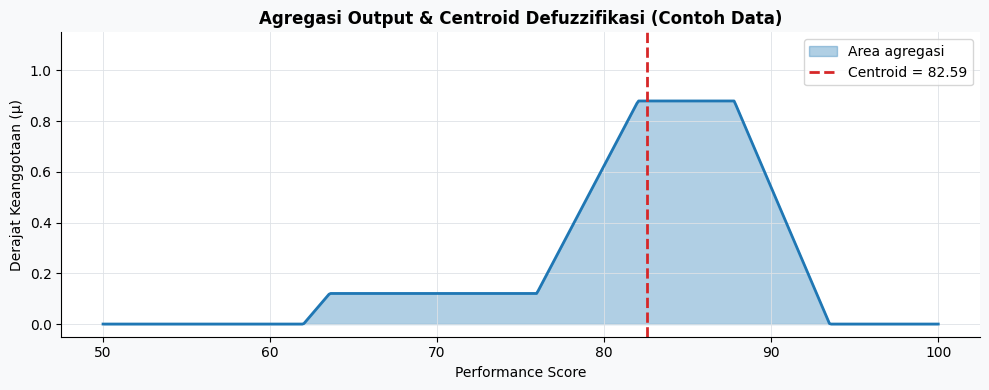

In [11]:
# Contoh defuzzifikasi pada data sampel
rules_sample  = evaluate_rules(f_sample)
agg_sample    = aggregate(rules_sample, OUTPUT_DOMAIN)
result_sample = defuzzify_centroid(agg_sample, OUTPUT_DOMAIN)

total_area = np.trapezoid(agg_sample, OUTPUT_DOMAIN)

print('=== Proses Defuzzifikasi Centroid (Mamdani) ===')
print(f'  Luas area agregat = {total_area:.4f}')
print(f'  Centroid (output) = {result_sample:.4f}')
print()

if result_sample >= 87:
    kategori = 'Tinggi'
elif result_sample >= 75:
    kategori = 'Sedang Atas'
elif result_sample >= 62:
    kategori = 'Sedang Bawah'
else:
    kategori = 'Rendah'

print(f'  Predicted Performance Score = {result_sample:.2f}  →  Kategori: {kategori}')

# ── Visualisasi area agregasi + garis centroid ────────────────────
fig, ax = plt.subplots(figsize=(10, 4), facecolor='#F8F9FA')
ax.set_facecolor('white')
ax.fill_between(OUTPUT_DOMAIN, agg_sample, alpha=0.35, color='#1F77B4', label='Area agregasi')
ax.plot(OUTPUT_DOMAIN, agg_sample, color='#1F77B4', lw=2)
ax.axvline(result_sample, color='#D62728', lw=2, ls='--',
           label=f'Centroid = {result_sample:.2f}')
ax.set_title('Agregasi Output & Centroid Defuzzifikasi (Contoh Data)', fontsize=12, fontweight='bold')
ax.set_xlabel('Performance Score', fontsize=10)
ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=10)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=10)
ax.grid(True, color='#DEE2E6', lw=0.6)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. Prediksi pada Seluruh Dataset

Pipeline fuzzy Mamdani diterapkan pada semua 5.000 baris data untuk menghasilkan prediksi `Performance Score` yang kemudian dibandingkan dengan nilai aktual.

In [12]:
print('Menjalankan prediksi fuzzy Mamdani pada seluruh dataset...')

df['Predicted_Mamdani'] = df.apply(predict_one, axis=1)

# Kategori berdasarkan Q1/Median/Q3 Performance Score
def to_kategori(score):
    if   score >= 87: return 'Tinggi'
    elif score >= 75: return 'Sedang Atas'
    elif score >= 62: return 'Sedang Bawah'
    else:             return 'Rendah'

df['Kategori_Aktual']    = df[OUTPUT_COL].apply(to_kategori)
df['Kategori_Prediksi']  = df['Predicted_Mamdani'].apply(to_kategori)

print(f'Selesai. Total baris diproses: {len(df):,}')
print()
print('=== Sample 10 Baris Hasil Prediksi ===')
print(df[[OUTPUT_COL, 'Predicted_Mamdani', 'Kategori_Aktual', 'Kategori_Prediksi']].head(10).to_string())

Menjalankan prediksi fuzzy Mamdani pada seluruh dataset...
Selesai. Total baris diproses: 5,000

=== Sample 10 Baris Hasil Prediksi ===
   Performance Score  Predicted_Mamdani Kategori_Aktual Kategori_Prediksi
0                 61          94.279449          Rendah            Tinggi
1                 91          75.000000          Tinggi       Sedang Atas
2                100          55.112885          Tinggi            Rendah
3                100          75.000000          Tinggi       Sedang Atas
4                 80          74.522441     Sedang Atas      Sedang Bawah
5                 53          69.161702          Rendah      Sedang Bawah
6                 59          75.000000          Rendah       Sedang Atas
7                 98          93.550377          Tinggi            Tinggi
8                 83          75.000000     Sedang Atas       Sedang Atas
9                 70          73.543693    Sedang Bawah      Sedang Bawah


---
## 8. Evaluasi Performa – MAE, MSE, RMSE

Evaluasi dilakukan menggunakan tiga metrik regresi standar:

$$\text{MAE}  = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$\text{MSE}  = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

In [13]:
actuals   = df[OUTPUT_COL].values
predicted = df['Predicted_Mamdani'].values
errors    = actuals - predicted

MAE  = np.mean(np.abs(errors))
MSE  = np.mean(errors ** 2)
RMSE = np.sqrt(MSE)

print('=' * 40)
print('   EVALUASI FUZZY MAMDANI')
print('=' * 40)
print(f'   MAE  = {MAE:.4f}')
print(f'   MSE  = {MSE:.4f}')
print(f'   RMSE = {RMSE:.4f}')
print('=' * 40)
print(f'   Range aktual   : [{actuals.min():.1f}, {actuals.max():.1f}]')
print(f'   Range prediksi : [{predicted.min():.2f}, {predicted.max():.2f}]')
print(f'   Rata-rata error: {np.mean(errors):.4f}')

   EVALUASI FUZZY MAMDANI
   MAE  = 14.9487
   MSE  = 331.7720
   RMSE = 18.2146
   Range aktual   : [50.0, 100.0]
   Range prediksi : [54.67, 94.94]
   Rata-rata error: 0.1434


---
## 9. Visualisasi Hasil

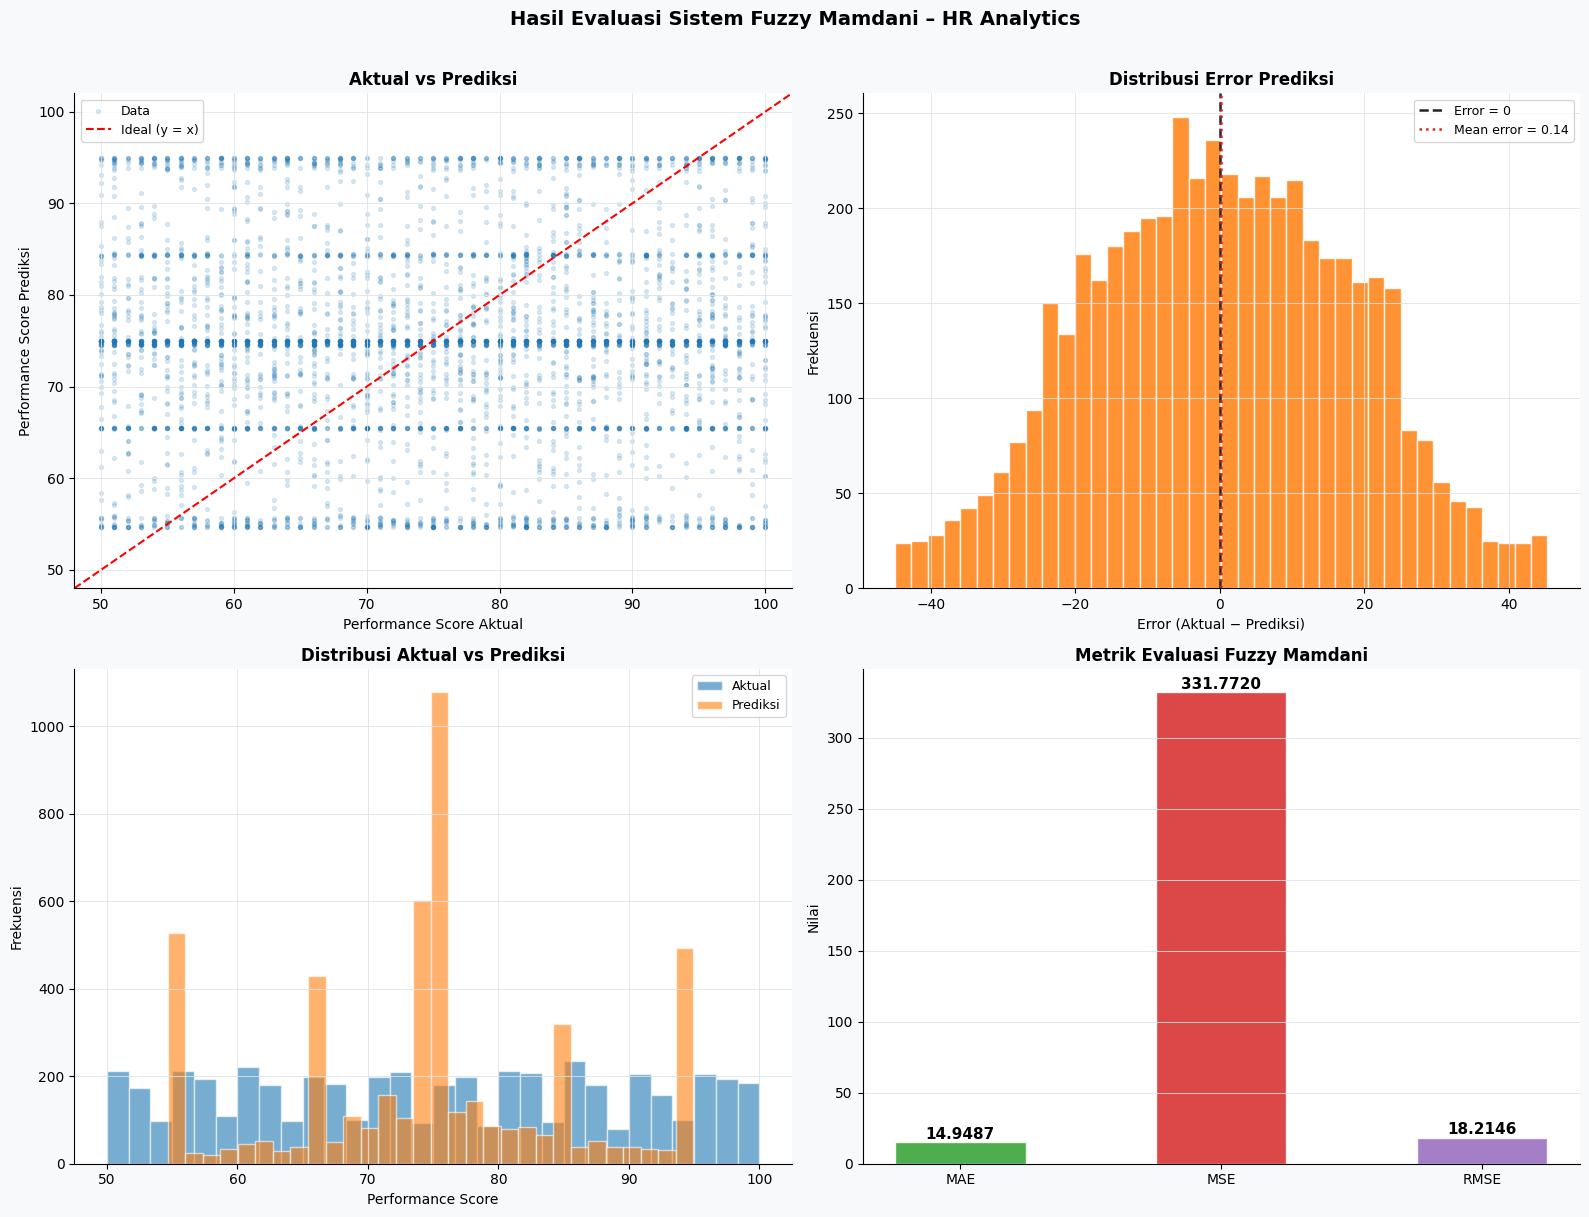

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#F8F9FA')

# ── 9.1 Scatter: Aktual vs Prediksi ───────────────────────────────
ax1 = axes[0, 0]
ax1.set_facecolor('white')
ax1.scatter(actuals, predicted, alpha=0.15, s=8, color='#1F77B4', label='Data')
lims = [min(actuals.min(), predicted.min()) - 2,
        max(actuals.max(), predicted.max()) + 2]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Ideal (y = x)')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Performance Score Aktual', fontsize=10)
ax1.set_ylabel('Performance Score Prediksi', fontsize=10)
ax1.set_title('Aktual vs Prediksi', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, color='#DEE2E6', lw=0.6)
ax1.spines[['top', 'right']].set_visible(False)

# ── 9.2 Histogram Error ───────────────────────────────────────────
ax2 = axes[0, 1]
ax2.set_facecolor('white')
ax2.hist(errors, bins=40, color='#FF7F0E', edgecolor='white', alpha=0.85)
ax2.axvline(0,           color='#212529', lw=1.8, ls='--', label='Error = 0')
ax2.axvline(np.mean(errors), color='#D62728', lw=1.8, ls=':',
            label=f'Mean error = {np.mean(errors):.2f}')
ax2.set_xlabel('Error (Aktual − Prediksi)', fontsize=10)
ax2.set_ylabel('Frekuensi', fontsize=10)
ax2.set_title('Distribusi Error Prediksi', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, color='#DEE2E6', lw=0.6)
ax2.spines[['top', 'right']].set_visible(False)

# ── 9.3 Distribusi Prediksi vs Aktual ─────────────────────────────
ax3 = axes[1, 0]
ax3.set_facecolor('white')
ax3.hist(actuals,   bins=30, alpha=0.6, color='#1F77B4', label='Aktual',   edgecolor='white')
ax3.hist(predicted, bins=30, alpha=0.6, color='#FF7F0E', label='Prediksi', edgecolor='white')
ax3.set_xlabel('Performance Score', fontsize=10)
ax3.set_ylabel('Frekuensi', fontsize=10)
ax3.set_title('Distribusi Aktual vs Prediksi', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, color='#DEE2E6', lw=0.6)
ax3.spines[['top', 'right']].set_visible(False)

# ── 9.4 Bar Metrik Evaluasi ───────────────────────────────────────
ax4 = axes[1, 1]
ax4.set_facecolor('white')
metrik = ['MAE', 'MSE', 'RMSE']
nilai  = [MAE, MSE, RMSE]
colors_bar = ['#2CA02C', '#D62728', '#9467BD']
bars = ax4.bar(metrik, nilai, color=colors_bar, edgecolor='white', alpha=0.85, width=0.5)
for bar, val in zip(bars, nilai):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_title('Metrik Evaluasi Fuzzy Mamdani', fontsize=12, fontweight='bold')
ax4.set_ylabel('Nilai', fontsize=10)
ax4.grid(True, axis='y', color='#DEE2E6', lw=0.6)
ax4.spines[['top', 'right']].set_visible(False)

fig.suptitle('Hasil Evaluasi Sistem Fuzzy Mamdani – HR Analytics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Ringkasan Sistem Fuzzy Mamdani

Cell ini mencetak ringkasan lengkap sistem yang telah dibangun — berguna sebagai acuan saat penggabungan notebook dan penyusunan laporan.

In [15]:
print('=' * 55)
print('        RINGKASAN SISTEM FUZZY MAMDANI')
print('=' * 55)
print(f'  Metode           : Fuzzy Mamdani (Linguistic / Klasik)')
print(f'  Total data       : {len(df):,} baris')
print(f'  Variabel input   : {len(INPUT_COLS)} variabel')
for c in INPUT_COLS:
    print(f'                     - {c}')
print(f'  Variabel output  : {OUTPUT_COL}')
print(f'  Jumlah himpunan  : 3–5 per variabel input')
print(f'  Fungsi keangg.   : Triangular & Trapezoidal')
print(f'  Jumlah rule      : 48 rule')
print(f'  Operator AND     : Minimum (t-norm)')
print(f'  Output per rule  : Himpunan fuzzy (clipped)')
print(f'  Domain output    : [50, 100] ({len(OUTPUT_DOMAIN)} titik)')
print(f'  Defuzzifikasi    : Centroid (Center of Gravity)')
print('-' * 55)
print(f'  MAE              : {MAE:.4f}')
print(f'  MSE              : {MSE:.4f}')
print(f'  RMSE             : {RMSE:.4f}')
print('=' * 55)

        RINGKASAN SISTEM FUZZY MAMDANI
  Metode           : Fuzzy Mamdani (Linguistic / Klasik)
  Total data       : 5,000 baris
  Variabel input   : 6 variabel
                     - KPI Score
                     - Attendance (%)
                     - Peer Rating
                     - Task Completion (%)
                     - Manager Feedback
                     - Training Hours
  Variabel output  : Performance Score
  Jumlah himpunan  : 3–5 per variabel input
  Fungsi keangg.   : Triangular & Trapezoidal
  Jumlah rule      : 48 rule
  Operator AND     : Minimum (t-norm)
  Output per rule  : Himpunan fuzzy (clipped)
  Domain output    : [50, 100] (500 titik)
  Defuzzifikasi    : Centroid (Center of Gravity)
-------------------------------------------------------
  MAE              : 14.9487
  MSE              : 331.7720
  RMSE             : 18.2146


In [16]:
low_weight = []
for _, row in df.iterrows():
    f = fuzzify(row)
    rules = evaluate_rules(f)
    total_area = np.trapezoid(aggregate(rules, OUTPUT_DOMAIN), OUTPUT_DOMAIN)
    low_weight.append(total_area)

df['total_area'] = low_weight
print(df['total_area'].describe())
print("Baris dengan total area < 0.1:", (df['total_area'] < 0.1).sum())

count    5000.000000
mean        6.671453
std         4.806029
min         0.000000
25%         2.280011
50%         7.252476
75%        10.012442
max        22.243239
Name: total_area, dtype: float64
Baris dengan total area < 0.1: 980
